# 13.5 2012 Federal Election Commission Database

**Bối cảnh**

Nguồn & phạm vi: Dữ liệu do Federal Election Commission (FEC) công bố từ các báo cáo tài chính vận động tranh cử liên bang (tổng thống, quốc hội), do ứng viên và ủy ban (party/PAC/super PAC…) nộp theo luật. FEC cung cấp cả tra cứu trực tuyến, tệp CSV “bulk data” và OpenFEC API để truy cập theo chu kỳ bầu cử (2011–2012).

Kỳ dữ liệu: Chu kỳ “2012” của FEC bao trùm 01/01/2011–31/12/2012 (mọi hoạt động gây quỹ/chi tiêu liên quan bầu cử 2012). 

Mức độ chi tiết: Dữ liệu bám theo các biểu mẫu/bản nộp gốc, có giao dịch cấp dòng (ví dụ: contribution – Schedule A; disbursement – Schedule B; independent expenditure – Schedule E), kèm mã tệp/ảnh để truy vết về hồ sơ gốc.

Quy mô hoạt động: Theo tổng hợp chính thức của FEC, toàn chu kỳ 2011–2012 các ứng viên liên bang, đảng và PAC nhận hơn 7,1 tỷ USD và chi gần 7,0 tỷ USD.

## 1. Nạp dữ liệu
Dữ liệu được lưu trong file CSV lớn tên là P00000001-ALL.csv (~150MB).

In [39]:
import pandas as pd
fec = pd.read_csv("dataset/fec/P00000001-ALL.csv", low_memory=False)
fec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001731 entries, 0 to 1001730
Data columns (total 16 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   cmte_id            1001731 non-null  object 
 1   cand_id            1001731 non-null  object 
 2   cand_nm            1001731 non-null  object 
 3   contbr_nm          1001731 non-null  object 
 4   contbr_city        1001712 non-null  object 
 5   contbr_st          1001727 non-null  object 
 6   contbr_zip         1001620 non-null  object 
 7   contbr_employer    988002 non-null   object 
 8   contbr_occupation  993301 non-null   object 
 9   contb_receipt_amt  1001731 non-null  float64
 10  contb_receipt_dt   1001731 non-null  object 
 11  receipt_desc       14166 non-null    object 
 12  memo_cd            92482 non-null    object 
 13  memo_text          97770 non-null    object 
 14  form_tp            1001731 non-null  object 
 15  file_num           1001731 non-n

**Nhận xét:**
- Bộ dữ liệu bao gồm 16 cột và có đến 1001731 dòng, tức rằng có đến 1 triệu lần bỏ phiếu quyên góp cá nhân cho các ứng viên trong cuộc bầu cử tổng thống Mỹ (2012) các cột bao gồm:

<div style="display:flex; justify-content:center;">
  <table style="margin:auto; border-collapse:collapse; min-width:720px;">
    <thead>
      <tr>
        <th style="border:1px solid #ccc; padding:8px; text-align:center;">Cột</th>
        <th style="border:1px solid #ccc; padding:8px; text-align:center;">Ý nghĩa</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="border:1px solid #eee; padding:8px;">cmte_id</td>
        <td style="border:1px solid #eee; padding:8px;">Mã Ủy ban nhận tiền (FEC committee ID) – chủ thể nhận khoản đóng góp.</td>
      </tr>
      <tr>|
        <td style="border:1px solid #eee; padding:8px;">cand_id</td>
        <td style="border:1px solid #eee; padding:8px;">Mã Ứng viên liên kết với ủy ban (nếu là ủy ban ứng cử).</td>
      </tr>
      <tr>
        <td style="border:1px solid #eee; padding:8px;">cand_nm</td>
        <td style="border:1px solid #eee; padding:8px;">Tên ứng viên liên kết (ví dụ: “OBAMA, BARACK”).</td>
      </tr>
      <tr>
        <td style="border:1px solid #eee; padding:8px;">contbr_nm</td>
        <td style="border:1px solid #eee; padding:8px;">Tên người đóng góp (cá nhân/tổ chức được khai báo).</td>
      </tr>
      <tr>
        <td style="border:1px solid #eee; padding:8px;">contbr_city</td>
        <td style="border:1px solid #eee; padding:8px;">Thành phố của người đóng góp.</td>
      </tr>
      <tr>
        <td style="border:1px solid #eee; padding:8px;">contbr_st (hoặc <em>contr_st</em>)</td>
        <td style="border:1px solid #eee; padding:8px;">Bang/tỉnh (mã 2 ký tự) của người đóng góp, ví dụ “CA”, “NY”.</td>
      </tr>
      <tr>
        <td style="border:1px solid #eee; padding:8px;">contbr_zip</td>
        <td style="border:1px solid #eee; padding:8px;">Mã ZIP của người đóng góp (thường 5 hoặc 9 chữ số).</td>
      </tr>
      <tr>
        <td style="border:1px solid #eee; padding:8px;">contbr_employer</td>
        <td style="border:1px solid #eee; padding:8px;">Nhà tuyển dụng (employer) do người đóng góp tự khai báo.</td>
      </tr>
      <tr>
        <td style="border:1px solid #eee; padding:8px;">contbr_occupation</td>
        <td style="border:1px solid #eee; padding:8px;">Nghề nghiệp do người đóng góp tự khai báo.</td>
      </tr>
      <tr>
        <td style="border:1px solid #eee; padding:8px;">contb_receipt_amt</td>
        <td style="border:1px solid #eee; padding:8px;">Số tiền đóng góp (USD) ghi nhận bởi ủy ban nhận.</td>
      </tr>
      <tr>
        <td style="border:1px solid #eee; padding:8px;">contb_receipt_dt</td>
        <td style="border:1px solid #eee; padding:8px;">Ngày nhận đóng góp (thường định dạng YYYY-MM-DD).</td>
      </tr>
      <tr>
        <td style="border:1px solid #eee; padding:8px;">receipt_desc</td>
        <td style="border:1px solid #eee; padding:8px;">Mô tả bổ sung cho khoản thu (nếu có), ví dụ hoàn trả, phân loại đặc biệt.</td>
      </tr>
      <tr>
        <td style="border:1px solid #eee; padding:8px;">memo_cd</td>
        <td style="border:1px solid #eee; padding:8px;">Cờ ghi chú (Y/N) cho biết dòng này là ghi chú/memo theo biểu mẫu FEC.</td>
      </tr>
      <tr>
        <td style="border:1px solid #eee; padding:8px;">memo_text</td>
        <td style="border:1px solid #eee; padding:8px;">Nội dung ghi chú kèm theo (nếu <code>memo_cd</code> là Y).</td>
      </tr>
      <tr>
        <td style="border:1px solid #eee; padding:8px;">form_tp</td>
        <td style="border:1px solid #eee; padding:8px;">Loại biểu mẫu/bản ghi (ví dụ SA11A1, SA17…), giúp truy vết quy tắc báo cáo.</td>
      </tr>
      <tr>
        <td style="border:1px solid #eee; padding:8px;">file_num</td>
        <td style="border:1px solid #eee; padding:8px;">Số hồ sơ FEC (filing number/image id) để tham chiếu về bản nộp gốc.</td>
      </tr>
    </tbody>
  </table>
</div>


### 1.1. Xác định danh sách ứng viên

In [40]:
unique_cands = fec["cand_nm"].unique()
print("Có tổng cộng " + str(len(unique_cands)) +" ứng viên tham gia tranh cử.")
print(unique_cands)

Có tổng cộng 13 ứng viên tham gia tranh cử.
['Bachmann, Michelle' 'Romney, Mitt' 'Obama, Barack'
 "Roemer, Charles E. 'Buddy' III" 'Pawlenty, Timothy' 'Johnson, Gary Earl'
 'Paul, Ron' 'Santorum, Rick' 'Cain, Herman' 'Gingrich, Newt'
 'McCotter, Thaddeus G' 'Huntsman, Jon' 'Perry, Rick']


**Nhận xét:**
- Trong cuộc bầu cử tổng thống Mỹ (2012) có đến 13 ứng cử viên tham gia tranh cử

<div style="display:flex; justify-content:center;">
  <table style="margin:auto; border-collapse:collapse; min-width:820px;">
    <thead>
      <tr>
        <th style="border:1px solid #ccc; padding:8px; text-align:center;">Ứng viên</th>
        <th style="border:1px solid #ccc; padding:8px; text-align:center;">Bang</th>
        <th style="border:1px solid #ccc; padding:8px; text-align:center;">Nghiêng 2012</th>
      </tr>
    </thead>
    <tbody>
      <tr><td style="border:1px solid #eee; padding:8px;">Barack Obama</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Illinois (IL)</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Dân chủ</td></tr>
      <tr><td style="border:1px solid #eee; padding:8px;">Mitt Romney</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Massachusetts (MA)</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Dân chủ</td></tr>
      <tr><td style="border:1px solid #eee; padding:8px;">Michelle Bachmann</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Minnesota (MN)</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Dân chủ</td></tr>
      <tr><td style="border:1px solid #eee; padding:8px;">Charles E. “Buddy” Roemer III</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Louisiana (LA)</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Cộng hòa</td></tr>
      <tr><td style="border:1px solid #eee; padding:8px;">Timothy (Tim) Pawlenty</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Minnesota (MN)</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Dân chủ</td></tr>
      <tr><td style="border:1px solid #eee; padding:8px;">Gary Johnson</td><td style="border:1px solid #eee; padding:8px; text-align:center;">New Mexico (NM)</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Dân chủ</td></tr>
      <tr><td style="border:1px solid #eee; padding:8px;">Ron Paul</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Texas (TX)</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Cộng hòa</td></tr>
      <tr><td style="border:1px solid #eee; padding:8px;">Rick Santorum</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Pennsylvania (PA)</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Dân chủ</td></tr>
      <tr><td style="border:1px solid #eee; padding:8px;">Herman Cain</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Georgia (GA)</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Cộng hòa</td></tr>
      <tr><td style="border:1px solid #eee; padding:8px;">Newt Gingrich</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Georgia (GA)</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Cộng hòa</td></tr>
      <tr><td style="border:1px solid #eee; padding:8px;">Thaddeus G. McCotter</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Michigan (MI)</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Dân chủ</td></tr>
      <tr><td style="border:1px solid #eee; padding:8px;">Jon Huntsman</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Utah (UT)</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Cộng hòa</td></tr>
      <tr><td style="border:1px solid #eee; padding:8px;">Rick Perry</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Texas (TX)</td><td style="border:1px solid #eee; padding:8px; text-align:center;">Cộng hòa</td></tr>
    </tbody>
  </table>
</div>



> Dựa vào bảng trên trong 13 ứng cử viên có đến 7 người ở Cộng hòa và 6 người Dân chủ, điều này cho thấy có sự cân bằng cho 2 phía.

### 1.2. Bổ sung thông tin đảng phái

Ta có thể thấy rằng trong tập dữ liệu này không có thông tin đảng phái của các ứng viên tham gia tranh cử.

Ta tạo một dictionary ánh xạ để chỉ định ứng viên thuộc đảng phái nào:
* Democrat : Đảng Dân chủ
* Republican: Đảng Cộng hòa

In [41]:
parties = {"Bachmann, Michelle": "Republican",
          "Cain, Herman": "Republican",
          "Gingrich, Newt": "Republican",
          "Huntsman, Jon": "Republican",
          "Johnson, Gary Earl": "Republican",
          "McCotter, Thaddeus G": "Republican",
          "Obama, Barack": "Democrat",
          "Paul, Ron": "Republican",
          "Pawlenty, Timothy": "Republican",
          "Perry, Rick": "Republican",
          "Roemer, Charles E. 'Buddy' III": "Republican",
          "Romney, Mitt": "Republican",
          "Santorum, Rick": "Republican"}

In [42]:
# thêm cột party (đảng)
fec["party"] = fec["cand_nm"].map(parties)
fec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001731 entries, 0 to 1001730
Data columns (total 17 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   cmte_id            1001731 non-null  object 
 1   cand_id            1001731 non-null  object 
 2   cand_nm            1001731 non-null  object 
 3   contbr_nm          1001731 non-null  object 
 4   contbr_city        1001712 non-null  object 
 5   contbr_st          1001727 non-null  object 
 6   contbr_zip         1001620 non-null  object 
 7   contbr_employer    988002 non-null   object 
 8   contbr_occupation  993301 non-null   object 
 9   contb_receipt_amt  1001731 non-null  float64
 10  contb_receipt_dt   1001731 non-null  object 
 11  receipt_desc       14166 non-null    object 
 12  memo_cd            92482 non-null    object 
 13  memo_text          97770 non-null    object 
 14  form_tp            1001731 non-null  object 
 15  file_num           1001731 non-n

> Hiện tại dữ liệu đã chia các đảng vào từng ứng viên tham gia bầu cử

**1) Trong năm 2012 thì tổng số phiếu bầu cho đảng phái nào chiếm đa số và tại sao?**

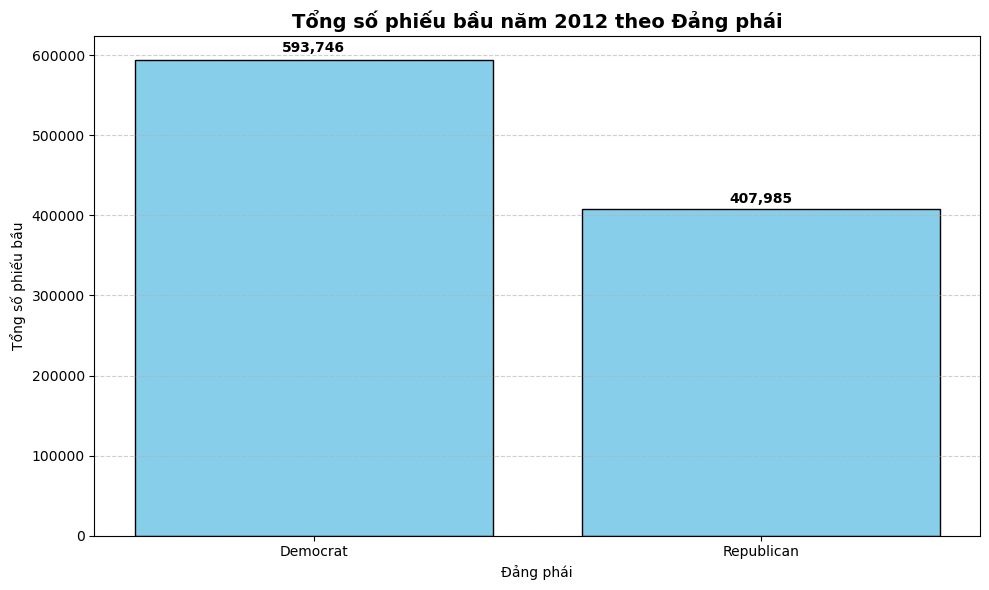

In [43]:
import matplotlib.pyplot as plt

num_party = fec["party"].value_counts()

plt.figure(figsize=(10,6))
bars = plt.bar(num_party.index, num_party.values,
               color='skyblue', edgecolor='black')

plt.title('Tổng số phiếu bầu năm 2012 theo Đảng phái', fontsize=14, fontweight='bold')
plt.ylabel('Tổng số phiếu bầu')
plt.xlabel('Đảng phái')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + (height * 0.01),
             f'{int(height):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("num_party.png")
plt.show()


**Nhận xét:**

Trong số 1001731 cá nhân đóng góp, thì có 593,769 phiếu cho Đảng Dân chủ, và 407,985 phiếu cho Đảng Cộng hòa.
- Số lượng các phiếu dành cho Đảng Dân chủ chiếm 3/2 số phiếu cho Đảng Cộng hòa vì có các chính sách và cơ cấu cử tri đúng đắn của Đảng, không có sự phân cực chính trị và chính sách cắt giảm chi tiêu công.

**Các thông tin trọng tâm về sự chênh lệch giữa các phiếu bầu:**

**Đối với Đảng Dân chủ:**

Các chính sách trọng tâm

- Kinh tế: Đảng Dân chủ tập trung vào phục hồi kinh tế sau cuộc Đại suy thoái, với các chính sách nhằm hỗ trợ tầng lớp trung lưu và người lao động. Điều này thu hút các cử tri lo lắng về an ninh việc làm và thu nhập.
- Chăm sóc sức khỏe: Việc thông qua Đạo luật Chăm sóc Sức khỏe Hợp túi tiền (ACA) là một điểm nhấn quan trọng. ACA giúp mở rộng bảo hiểm y tế cho hàng triệu người, nhận được sự ủng hộ mạnh mẽ từ các cử tri quan tâm đến y tế.
- Bảo vệ môi trường: Lập trường của đảng về chống biến đổi khí hậu và đầu tư vào năng lượng sạch đã thu hút những cử tri quan tâm đến vấn đề môi trường. 

Cơ cấu cử tri

- Sự đa dạng chủng tộc và giới tính: Đảng Dân chủ có cơ sở cử tri đa dạng, bao gồm phụ nữ, người Mỹ gốc Phi, người gốc Tây Ban Nha và người Mỹ gốc Á. Các chính sách của đảng về quyền công dân và bình đẳng xã hội đã củng cố sự ủng hộ của các nhóm này.
- Cử tri trẻ: Giới trẻ thường có xu hướng ủng hộ Đảng Dân chủ vì các quan điểm cởi mở và tiến bộ về xã hội, hôn nhân đồng giới và môi trường.
- Khu vực địa lý: Đảng Dân chủ nhận được sự ủng hộ mạnh mẽ tại các thành phố lớn và khu vực đô thị, nơi có nhiều cử tri thuộc tầng lớp lao động và các dân tộc thiểu số. 

**Đối lập với Đảng Cộng hòa**

- Sự phân cực chính trị: Trong những năm gần đây, sự phân cực giữa hai đảng đã ngày càng sâu sắc. Một số cử tri bỏ phiếu cho Đảng Dân chủ không chỉ vì ủng hộ các chính sách của đảng này, mà còn vì bất đồng với các chính sách của Đảng Cộng hòa về kinh tế, nhập cư và các vấn đề xã hội khác.
- Sự phản đối các chính sách cắt giảm chi tiêu công: Một số cử tri không đồng tình với việc Đảng Cộng hòa chủ trương cắt giảm chi tiêu công, đặc biệt trong bối cảnh nền kinh tế đang hồi phục.

## 2. Làm sạch dữ liệu

In [44]:
(fec["contb_receipt_amt"] > 0).value_counts()

contb_receipt_amt
True     991475
False     10256
Name: count, dtype: int64

In [45]:
fec = fec[fec["contb_receipt_amt"] > 0]

**Nhận xét:**
- Bộ dữ liệu gồm cả khoản đóng góp và hoàn tiền (refund).

- Lọc lại chỉ lấy các khoản đóng góp dương (> 0) để phân tích

>Kết quả: có 991475 bản ghi hợp lệ

**2) Trong số 13 ứng cử viên, ai là ứng cử viên được ủng hộ nhiều nhất và lý do?**

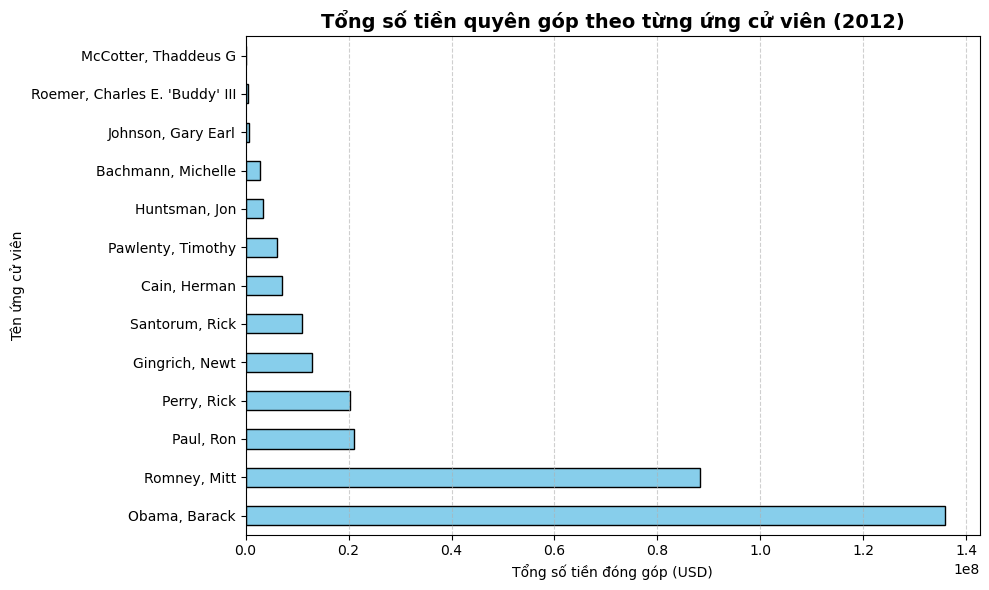

In [46]:
import matplotlib.pyplot as plt

# Tính tổng đóng góp theo ứng cử viên
by_cand = fec.groupby('cand_nm')['contb_receipt_amt'].sum()
top_candidates = by_cand.sort_values(ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(10,6))
top_candidates.plot(kind='barh', color='skyblue', edgecolor='black')

plt.title('Tổng số tiền quyên góp theo từng ứng cử viên (2012)', fontsize=14, fontweight='bold')
plt.xlabel('Tổng số tiền đóng góp (USD)')
plt.ylabel('Tên ứng cử viên')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


**Nhận xét:**

Trong số 13 ứng cử viên tranh cử thì cái tên **Obama, Barack** và **Romney, Mitt** là 2 ứng cử viên được sự ủng hộ nhiều nhất vì có thể thấy **Obama, Barack** và **Romney, Mitt** đều là 2 ứng cử viên của Đảng Dân chủ. Mà số lượng phiếu bầu cho Đảng Dân chủ chiếm đa số cho nên mọi ứng cử viên nằm trong Đảng này được ủng hộ đa số.
> Dựa vào dự kiến đó ta sẽ tập trung vào **Obama, Barack** và **Romney, Mitt** để tối giản dữ liệu.

In [47]:
fec_mrbo = fec[fec["cand_nm"].isin(["Obama, Barack", "Romney, Mitt"])]
fec_mrbo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 694282 entries, 411 to 701385
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   cmte_id            694282 non-null  object 
 1   cand_id            694282 non-null  object 
 2   cand_nm            694282 non-null  object 
 3   contbr_nm          694282 non-null  object 
 4   contbr_city        694275 non-null  object 
 5   contbr_st          694278 non-null  object 
 6   contbr_zip         694234 non-null  object 
 7   contbr_employer    693607 non-null  object 
 8   contbr_occupation  693524 non-null  object 
 9   contb_receipt_amt  694282 non-null  float64
 10  contb_receipt_dt   694282 non-null  object 
 11  receipt_desc       2345 non-null    object 
 12  memo_cd            87387 non-null   object 
 13  memo_text          90672 non-null   object 
 14  form_tp            694282 non-null  object 
 15  file_num           694282 non-null  int64  
 16  party

**Nhận xét:**
- Sau khi biết được **Obama, Barack** và **Romney, Mitt** là 2 cái tên cần quan tâm, thì sau khi lọc dữ liệu sẽ còn 694282 dòng (1.5 lần tổng dữ liệu bầu cử)

## 3. Phân tích dữ liệu


### 3.1 Phân tích mô tả

**1) Mức độ trung bình của mỗi người ủng hộ là bao nhiêu?**

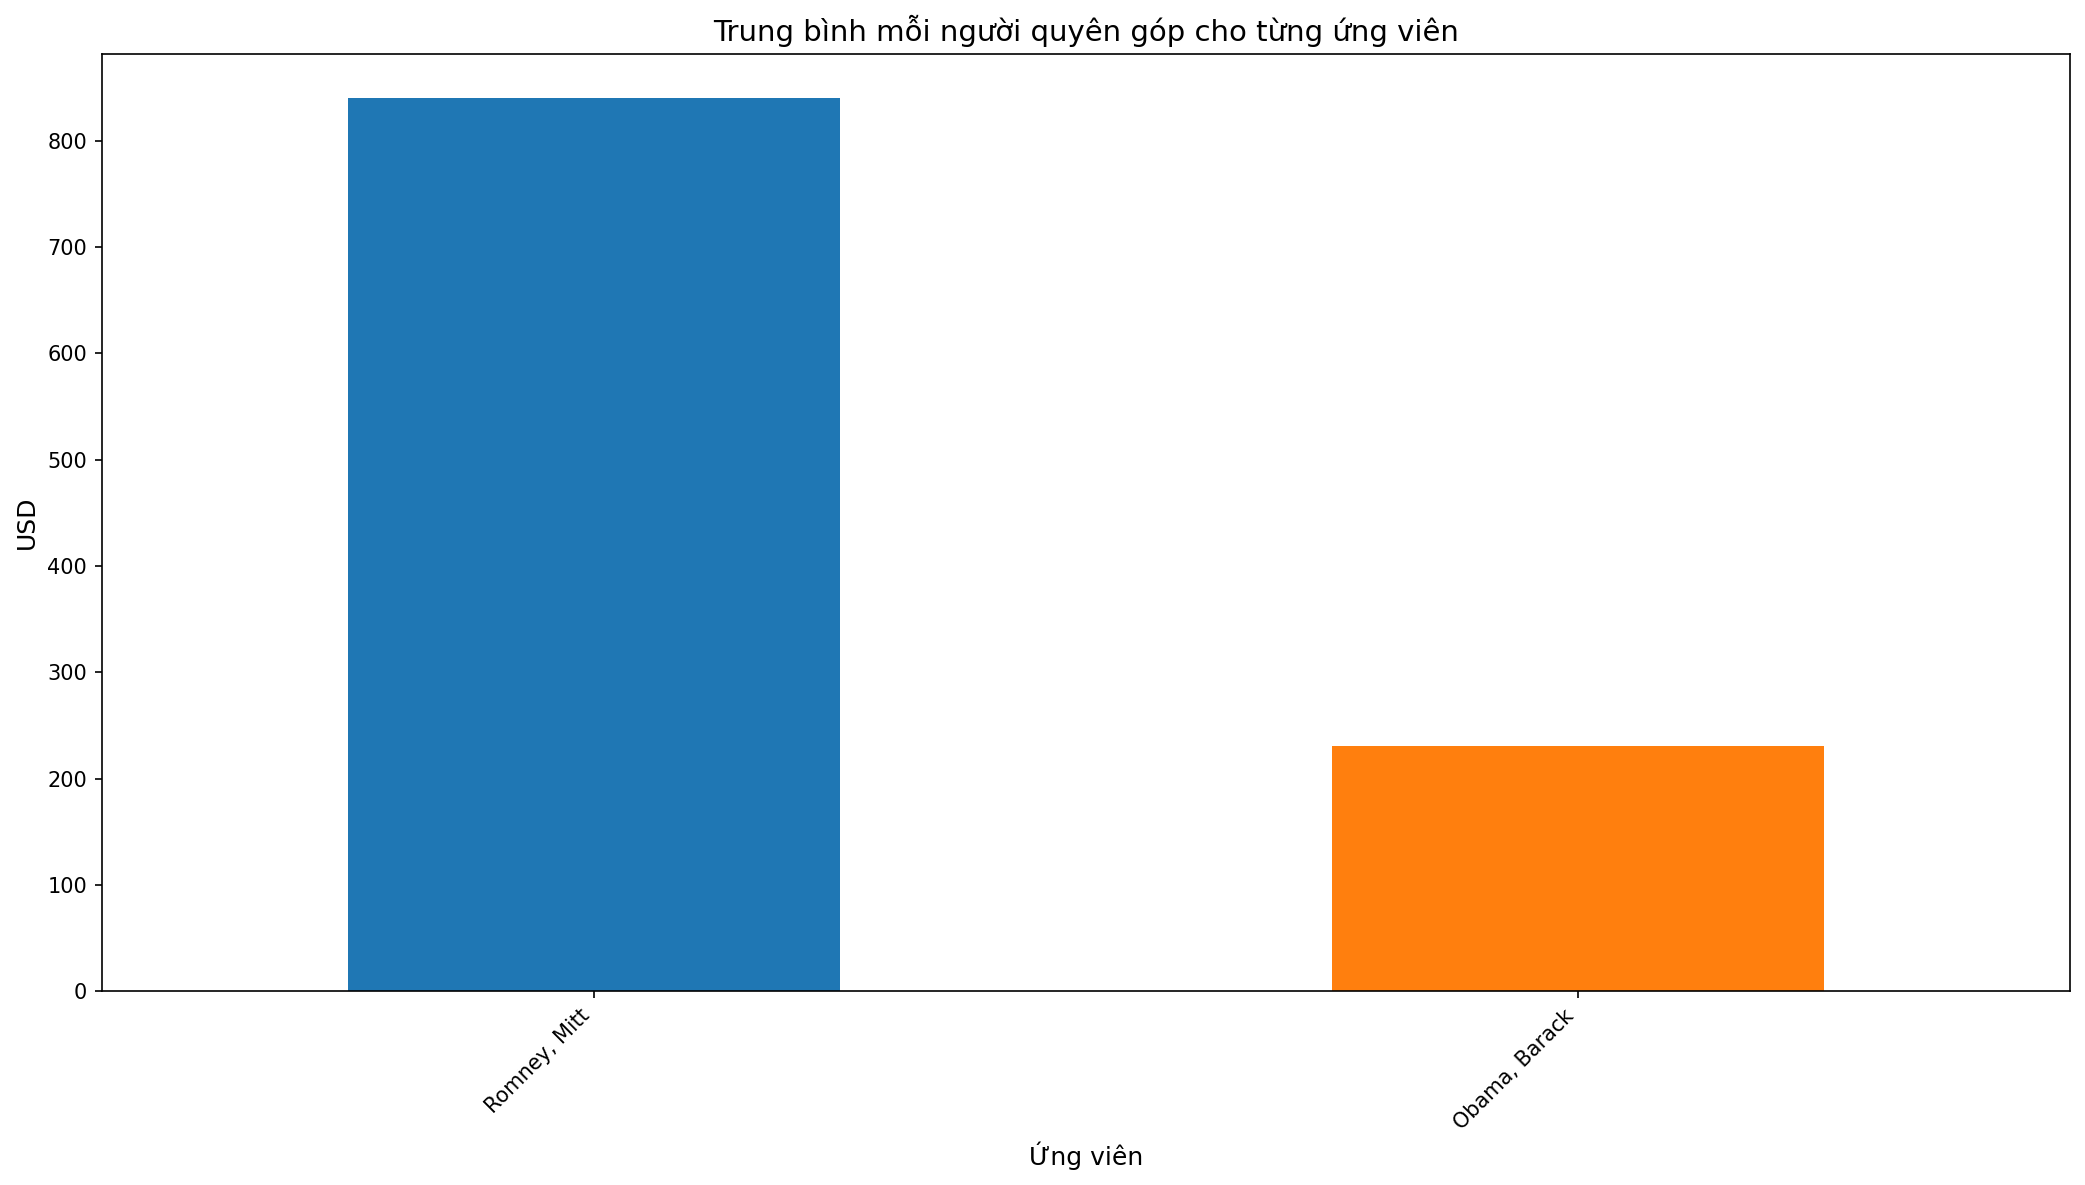

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Median & phân vị
fec_mrbo.groupby("cand_nm")["contb_receipt_amt"].agg(
    n_txn="size", mean="mean", median="median", p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75)
)

# Tỷ trọng small-dollar (< $200)
cut = fec.assign(is_small = fec["contb_receipt_amt"] < 200)
cut.groupby("cand_nm")["is_small"].mean().sort_values(ascending=False)  # tỷ lệ %


plt.figure(figsize=(14, 8), dpi=150)  # <- TĂNG KÍCH THƯỚC & ĐỘ NÉT
average_donation.plot(kind="bar", color=["#1f77b4", "#ff7f0e"])
plt.title("Trung bình mỗi người quyên góp cho từng ứng viên", fontsize=14)
plt.ylabel("USD", fontsize=12)
plt.xlabel("Ứng viên", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.tight_layout()
plt.show()


**Nhận xét:**

Theo luật tài chính tranh cử Mỹ (FECA) vào năm 2011-2012:
- Một cá nhân có thể ủng hộ tối đa 2,500 USD cho một ứng viên
- 30,800 USD/năm cho một ủy ban đảng cáp quốc gia (DNC/RNC, DSCC/DCCC/NRSC/NRCC, …).

Với 2 ứng cử viên **Obama, Barack** và **Romney, Mitt** thì có sự chênh lệch lớn giữa 2 ứng viên:

**Romney, Mitt**
- Với con số trung bình > 800 USD dựa nhiều vào các khoản quyên góp giá trị lớn (gần mức trần cá nhân theo luật thời điểm đó), nên giá trị trung bình cao. Các khoản lớn làm “kéo” trung bình lên.

**Obama, Barack**
- Do chiến lược grassroots/small-dollar (nhiều khoản nhỏ, quy mô đông người ủng hộ), nên trung bình thấp nhưng tổng số giao dịch thường rất lớn, giúp tổng huy động vẫn mạnh. (~200 USD)
> Dựa vào các con số này có thể thấy 2 nguồn sức mạnh đối lập: một bên là cộng đồng, một bên là giới tinh hoa

2) Các bang nào quyên góp nhiều nhất?

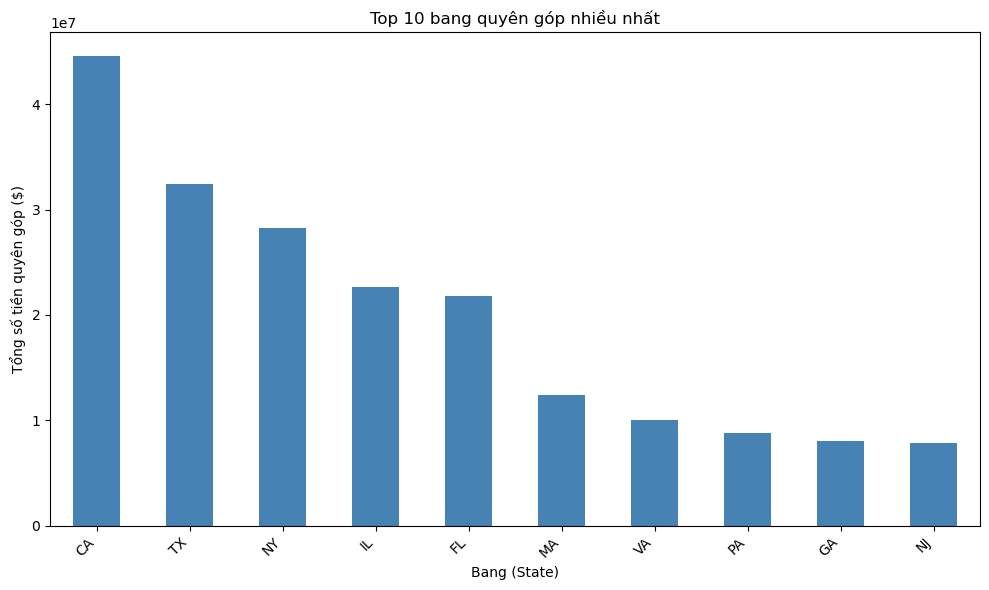

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Nhóm dữ liệu theo bang (State) và tính tổng số tiền quyên góp
total_by_state = fec.groupby("contbr_st")["contb_receipt_amt"].sum().sort_values(ascending=False)


# Vẽ biểu đồ
plt.figure(figsize=(10,6))
total_by_state.head(10).plot(kind="bar", color="steelblue")
plt.title("Top 10 bang quyên góp nhiều nhất")
plt.xlabel("Bang (State)")
plt.ylabel("Tổng số tiền quyên góp ($)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("top10_states_donations.png")
plt.show()


**Nhận xét:**
- Các bang như California, New York, Texas, Florida  nằm trong nhóm quyên góp cao nhất vì dân số lớn, thu nhập cao, và là trung tâm chính trị - kinh tế - truyền thông của Hoa Kỳ.

### 3.2. Phân tích tương quan

**1) So sánh số lượng quyên góp nhỏ với với quyên góp lớn**

Theo FEC thì tổng đóng góp một cá nhân < $200 vì đó là ranh giới báo cáo (itemization) của FEC và là chuẩn small-dollar được chấp nhận rộng rãi.

In [50]:
# Lọc quyên góp nhỏ (<200 USD)
small_donations = fec_mrbo[fec_mrbo["contb_receipt_amt"] < 200]

# Tổng số tiền quyên góp nhỏ theo ứng viên
small_donation_sum = small_donations.groupby("cand_nm")["contb_receipt_amt"].count().sort_values(ascending=False)

print("Tổng quyên góp nhỏ (<$200) của mỗi ứng viên:")
small_donation_sum


Tổng quyên góp nhỏ (<$200) của mỗi ứng viên:


cand_nm
Obama, Barack    438321
Romney, Mitt      38820
Name: contb_receipt_amt, dtype: int64

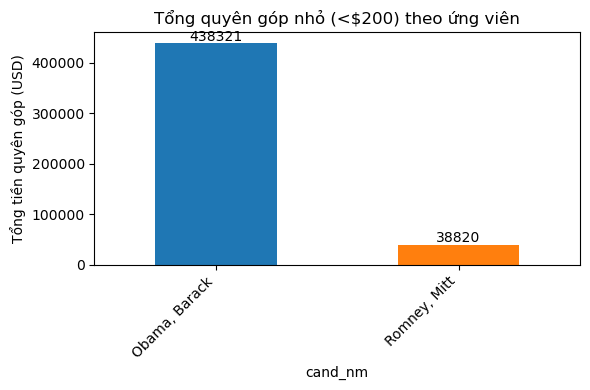

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
small_donation_sum.plot(kind="bar", color=["#1f77b4", "#ff7f0e"])
for index, value in enumerate(small_donation_sum):
    plt.text(index, value + 5000, str(value), ha='center')
plt.title("Tổng quyên góp nhỏ (<$200) theo ứng viên")
plt.ylabel("Tổng tiền quyên góp (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("small_donation.png")
plt.show()

**Nhận xét:**

Chênh lệch rất lớn: Obama có tổng small-dollar ≈ $438k, Romney ≈ $38.8k ⇒ Obama cao hơn ~11×.

Hàm ý chiến lược:

- Obama: mạng lưới quyên góp đại chúng/online mạnh, nhiều khoản nhỏ → độ rộng ủng hộ cao.

- Romney: phụ thuộc hơn vào khoản lớn ⇒ phần “< $200” chiếm tỷ trọng nhỏ.

**2) Tỷ lệ số tiền quyên góp cho 2 ứng cử viên là bao nhiêu?**

Sử dụng hàm cắt để phân chia số tiền đóng góp thành các nhóm theo quy mô đóng góp

In [52]:
import numpy as np
bins = np.array([0, 100, 1000, 10000, 100_000, 1_000_000, 10_000_000])
labels = pd.cut(fec_mrbo["contb_receipt_amt"], bins)
labels

411          (0, 100]
412       (100, 1000]
413       (100, 1000]
414          (0, 100]
415          (0, 100]
             ...     
701381       (0, 100]
701382    (100, 1000]
701383       (0, 100]
701384       (0, 100]
701385    (100, 1000]
Name: contb_receipt_amt, Length: 694282, dtype: category
Categories (6, interval[int64, right]): [(0, 100] < (100, 1000] < (1000, 10000] < (10000, 100000] < (100000, 1000000] < (1000000, 10000000]]

Phân bố số lượng đóng góp

In [53]:
grouped = fec_mrbo.groupby(["cand_nm", labels])
grouped.size().unstack(level=0)

C:\Users\luong\AppData\Local\Temp\ipykernel_2068\3276222007.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = fec_mrbo.groupby(["cand_nm", labels])


cand_nm,"Obama, Barack","Romney, Mitt"
contb_receipt_amt,,
"(0, 100]",412843,35611
"(100, 1000]",153991,43357
"(1000, 10000]",22284,26186
"(10000, 100000]",2,1
"(100000, 1000000]",3,0
"(1000000, 10000000]",4,0


Nhận xét:
* Obama nhận nhiều khoản nhỏ (≤ $1000) hơn hẳn Romney.

* Romney có tỷ lệ đóng góp lớn (≥ $1000) cao hơn.

Chuẩn hóa tỷ lệ đóng góp theo quy mô

In [54]:
bucket_sums = grouped["contb_receipt_amt"].sum().unstack(level=0)
normed_sums = bucket_sums.div(bucket_sums.sum(axis="columns"), axis="index")
normed_sums

cand_nm,"Obama, Barack","Romney, Mitt"
contb_receipt_amt,,
"(0, 100]",0.910897,0.089103
"(100, 1000]",0.710176,0.289824
"(1000, 10000]",0.447326,0.552674
"(10000, 100000]",0.823120,0.176880
"(100000, 1000000]",1.000000,0.000000
"(1000000, 10000000]",1.000000,0.000000


Bây giờ ta sẽ trực quan nó bằng biểu đồ cột.

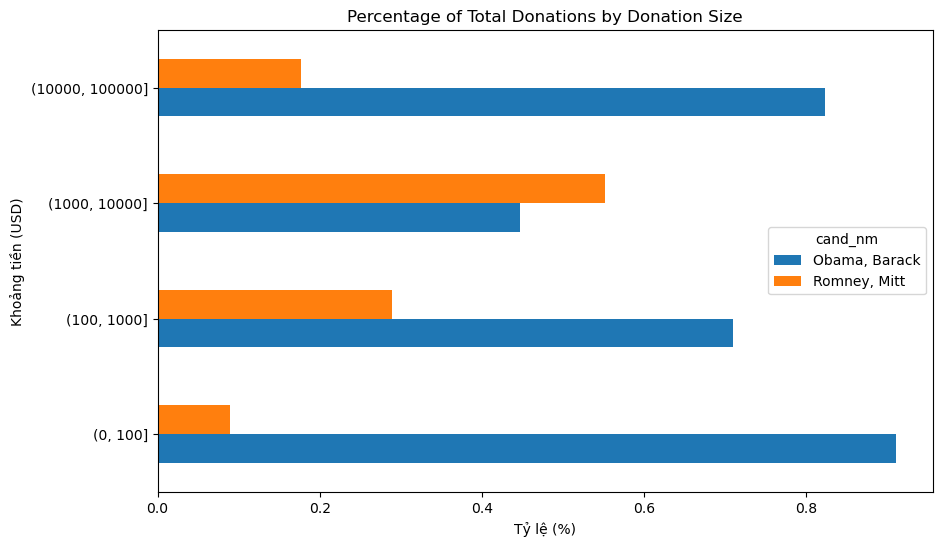

In [55]:
import matplotlib.pyplot as plt

normed_sums[:-2].plot(kind="barh", figsize=(10,6))
plt.title("Percentage of Total Donations by Donation Size")
plt.xlabel("Tỷ lệ (%)")
plt.ylabel("Khoảng tiền (USD)")
plt.savefig("percentage_of_total_donations.png")
plt.show()


**Nhận xét:**

**Obama, Barack**

Tỷ trọng rất cao ở nhóm nhỏ: (0–100] ≈ 92% và (100–1,000] ≈ 70% 

Ở nhóm (1,000–10,000] tỷ trọng giảm (~45%).

Nhóm (10,000–100,000] lại cao (~82%) có thể phân bổ về đảng/ủy ban liên quan, không phải “đóng trực tiếp” cho ủy ban ứng viên.

**Romney, Mitt**

Tỷ trọng trung-đến-lớn nổi bật: (1,000–10,000] ~ 55% và phần nhóm (100–1,000] cũng đáng kể (~30%).

Nhỏ < $100 chiếm tỷ trọng thấp (~9%) → phù hợp phong cách dựa vào donor lớn/ít giao dịch nhỏ.

**3) Trong số những người bầu cử, nghề nghiệp nào chiếm đa số?**

##### Thống kê số lượng nghề nghiệp

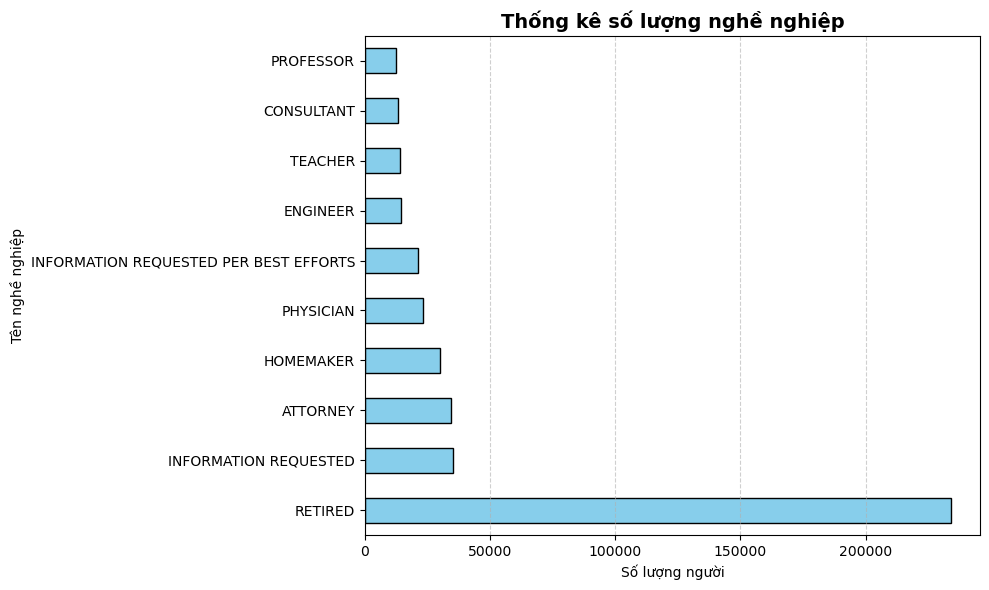

In [56]:
result = fec["contbr_occupation"].value_counts()[:10]

# Vẽ biểu đồ
plt.figure(figsize=(10,6))
result.plot(kind='barh', color='skyblue', edgecolor='black')

plt.title('Thống kê số lượng nghề nghiệp', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng người')
plt.ylabel('Tên nghề nghiệp')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("tk1.png")
plt.show()

**Nhận xét:**

RETIRED (nghỉ hưu) áp đảo tuyệt đối. Với biểu đồ số lượng người, đây là điều thường thấy vì người về hưu đóng góp rất nhiều.

Hai nhãn “INFORMATION REQUESTED” và “INFORMATION REQUESTED PER BEST EFFORTS” là placeholder khi ủy ban chưa thu thập đủ nghề nghiệp không phải nghề thực. 

Các nhóm còn lại nổi bật lần lượt: ATTORNEY, HOMEMAKER, PHYSICIAN, ENGINEER, TEACHER, CONSULTANT, PROFESSOR — cho thấy nhà tài trợ tập trung ở nhóm chuyên môn/thu nhập trung–cao.

**4) Sự phân bố của nghề nghiệp so với 2 Đảng như thế nào?**

In [57]:
by_occupation = fec.pivot_table("contb_receipt_amt",
                                index="contbr_occupation",
                                columns="party", aggfunc="sum")
over_2mm = by_occupation[by_occupation.sum(axis="columns") > 2000000]
over_2mm

party,Democrat,Republican
contbr_occupation,,
ATTORNEY,11141982.97,7477194.43
C.E.O.,1690.00,2592983.11
CEO,2073284.79,1618057.41
CONSULTANT,2459912.71,2544725.45
ENGINEER,951525.55,1818373.70
EXECUTIVE,1355161.05,4138850.09
HOMEMAKER,4248875.80,13634275.78
INFORMATION REQUESTED,4866973.96,3896615.74
INFORMATION REQUESTED PER BEST EFFORTS,NaN,16340533.64


Từ kết quả cho thấy các nghề giàu ảnh hưởng gồm: RETIRED, ATTORNEY, HOMEMAKER.

C:\Users\luong\AppData\Local\Temp\ipykernel_2068\3503552199.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)


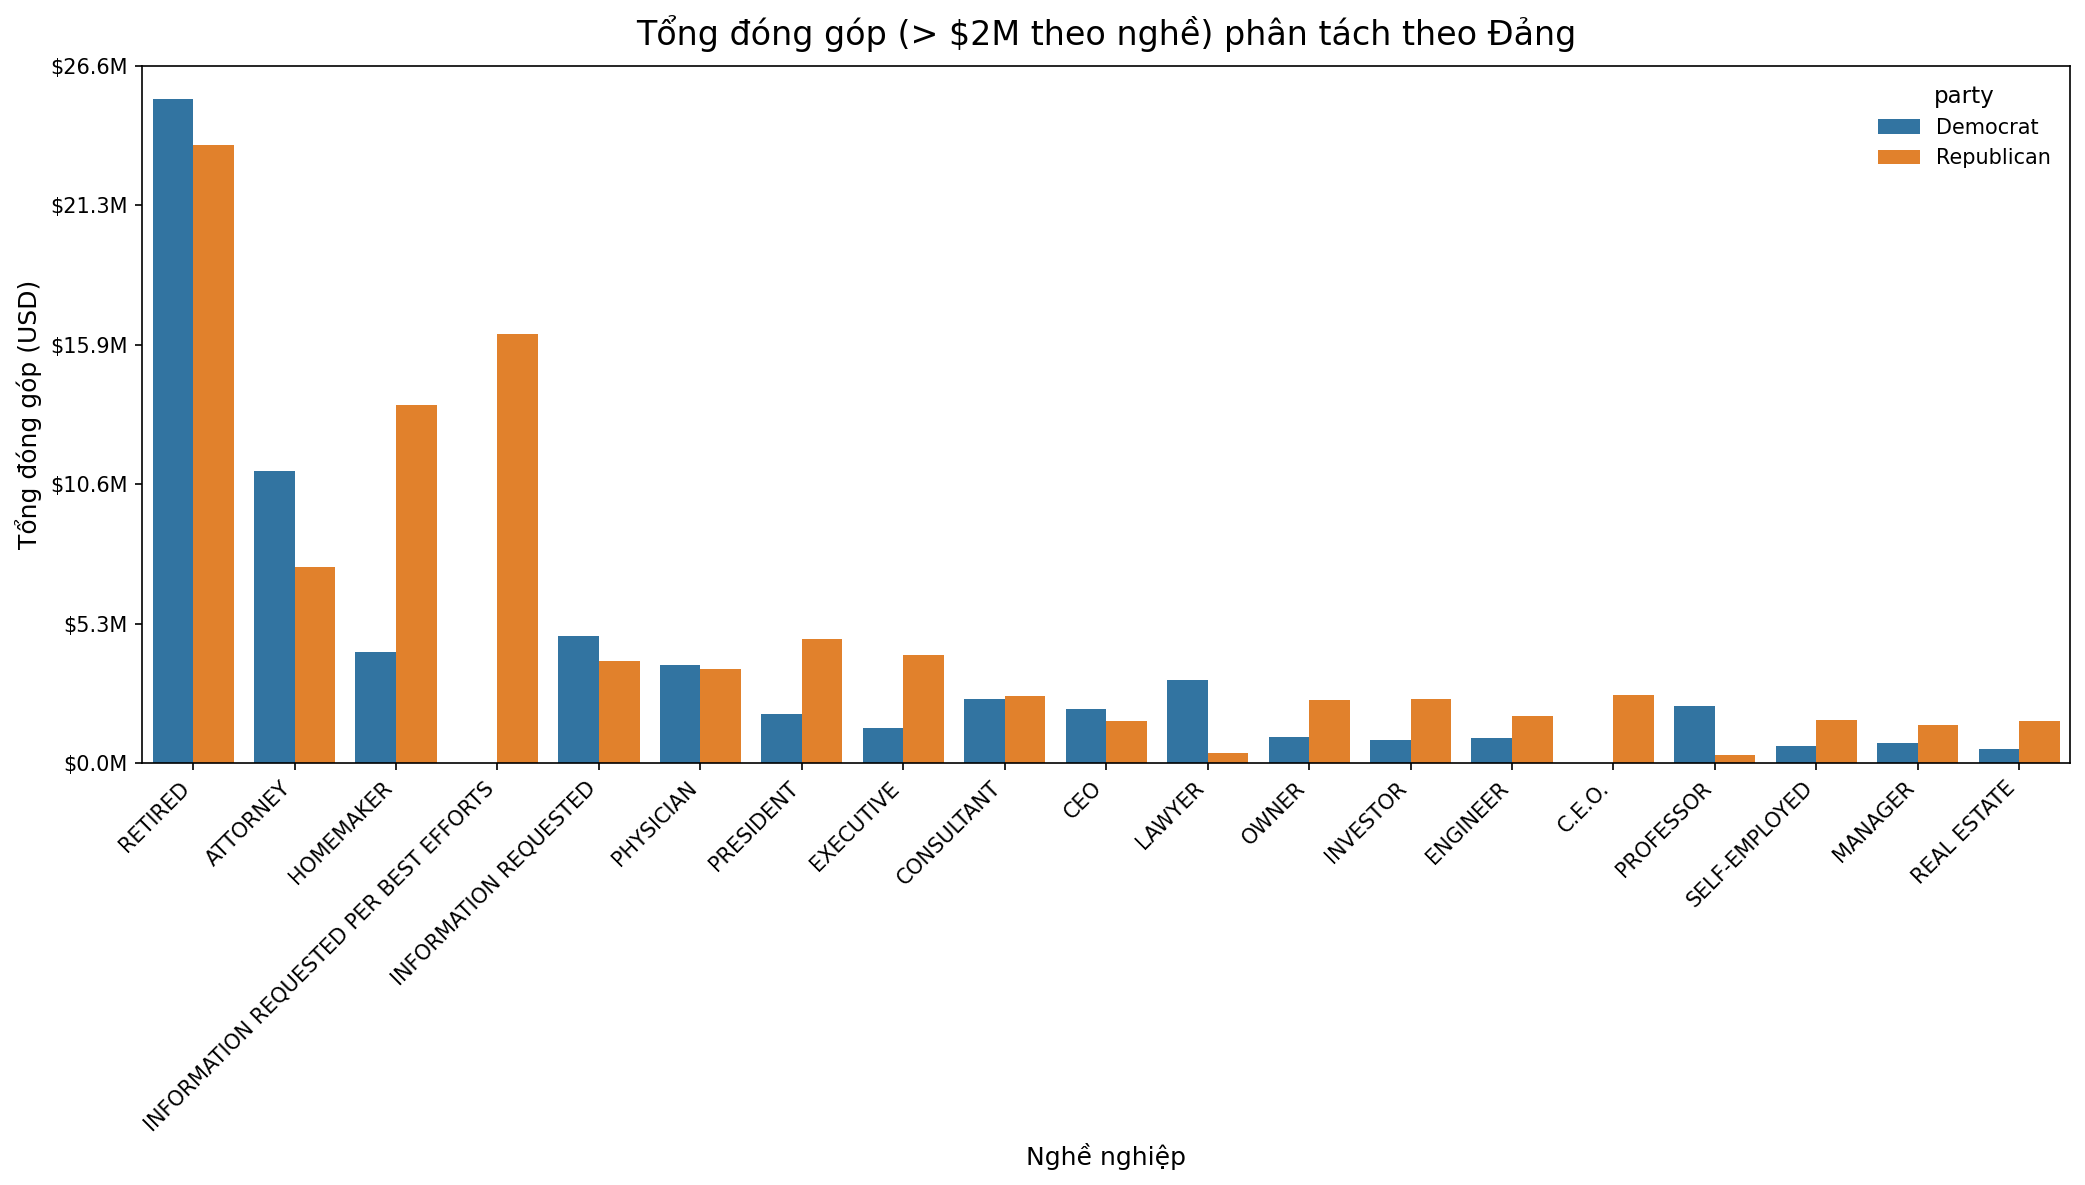

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# over_2mm: index = contbr_occupation, columns = party, values = sum(contb_receipt_amt)

# Sắp xếp nghề theo tổng đóng góp giảm dần để dễ đọc
order_occ = over_2mm.sum(axis=1).sort_values(ascending=False).index

# Chuyển sang dạng dài để vẽ với seaborn
df_plot = (
    over_2mm.loc[order_occ]
            .reset_index()
            .melt(id_vars="contbr_occupation", var_name="party", value_name="amount")
)

# Vẽ
fig, ax = plt.subplots(figsize=(14, 8), dpi=150)
sns.barplot(
    data=df_plot,
    x="contbr_occupation",
    y="amount",
    hue="party",
    order=order_occ,
    ax=ax
)

# Tiêu đề & nhãn trục
ax.set_title("Tổng đóng góp (> $2M theo nghề) phân tách theo Đảng", fontsize=16, pad=10)
ax.set_xlabel("Nghề nghiệp", fontsize=12)
ax.set_ylabel("Tổng đóng góp (USD)", fontsize=12)

# X ticks & Y ticks
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=10)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"${y/1e6:.1f}M"))
ymax = ax.get_ylim()[1]
ax.set_yticks(np.linspace(0, ymax, 6))
ax.tick_params(axis="y", labelsize=10)

# Legend
ax.legend(title="party", title_fontsize=11, fontsize=10, frameon=False, loc="upper right")

plt.tight_layout()
plt.show()


**Nhận xét:**

RETIRED vẫn là nhóm áp đảo ở cả hai đảng, phía Dân chủ có vẻ nhỉnh hơn chút.

Dân chủ trội ở: ATTORNEY (luật sư), LAWYER, và một số nhãn quản trị nhỏ (PRESIDENT nhẹ).

Cộng hòa trội ở: HOMEMAKER (rất rõ, vượt xa), EXECUTIVE/CEO, CONSULTANT, INVESTOR, ENGINEER, PHYSICIAN, REAL ESTATE, và PROFESSOR (trong đồ thị này cao hơn Dân chủ).

>Hai nhãn “INFORMATION REQUESTED / …BEST EFFORTS” là placeholder (thiếu thông tin nghề), không phải nghề thực nhưng lại khá lớn—nên tách/loại khi rút kết luận nội dung.

**5) Top nghề nghiệp và công ty quyên góp cho từng ứng cử viên**

C:\Users\luong\AppData\Local\Temp\ipykernel_2068\2369046225.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_occ = grouped.apply(get_top_amounts, "contbr_occupation", n=7).reset_index()


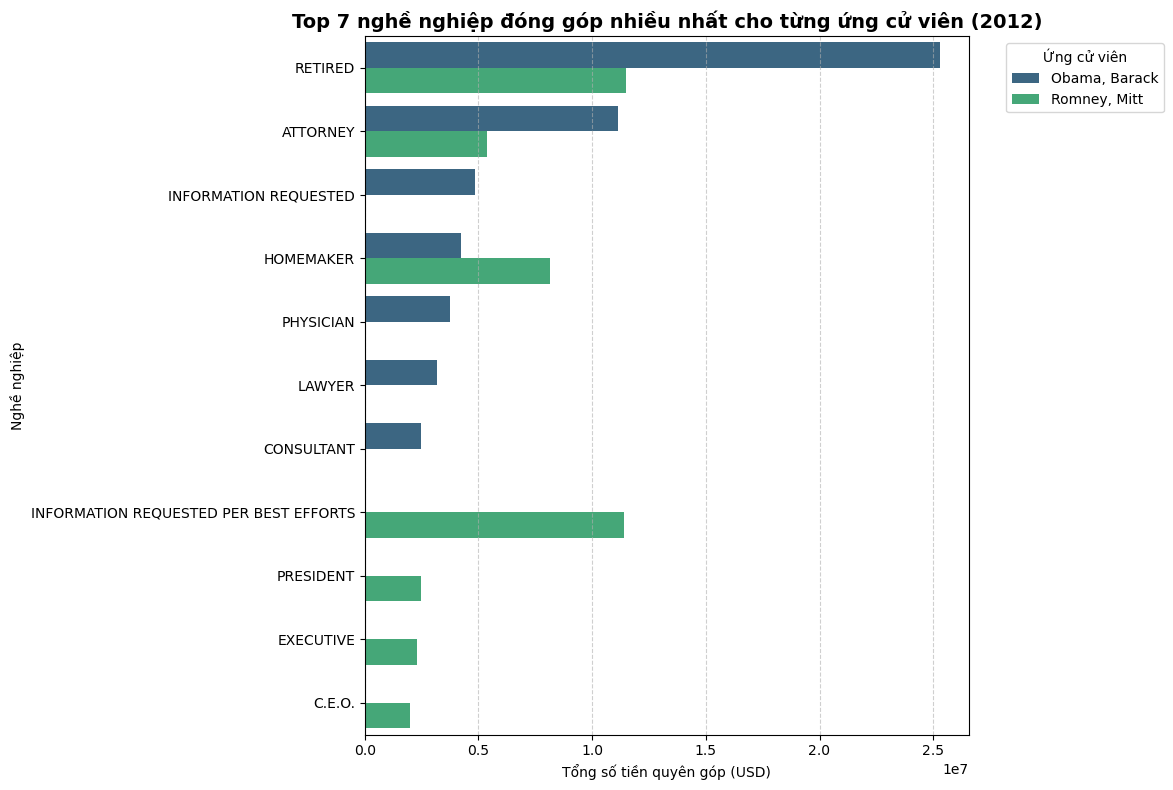

In [63]:
import seaborn as sns
def get_top_amounts(group, key, n=5):
  totals = group.groupby(key)["contb_receipt_amt"].sum()
  return totals.nlargest(n)
grouped = fec_mrbo.groupby("cand_nm")
top_occ = grouped.apply(get_top_amounts, "contbr_occupation", n=7).reset_index()

# Đổi tên cột cho dễ hiểu
top_occ.columns = ["Candidate", "Occupation", "Total_Amount"]

# Vẽ biểu đồ
plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_occ,
    y="Occupation",
    x="Total_Amount",
    hue="Candidate",
    dodge=True,
    palette="viridis"
)

plt.title("Top 7 nghề nghiệp đóng góp nhiều nhất cho từng ứng cử viên (2012)", fontsize=14, fontweight="bold")
plt.xlabel("Tổng số tiền quyên góp (USD)")
plt.ylabel("Nghề nghiệp")
plt.legend(title="Ứng cử viên", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("tk2.png")
plt.show()

**Nhận xét:**

RETIRED áp đảo cho cả hai ứng viên, đặc biệt Obama (~2.5×10⁷ USD) cao hơn Romney nhóm về hưu là “xương sống” tài trợ của cả hai bên.

Obama nổi bật ở ATTORNEY/Lawyer, Consultant, Physician → thiên về các ngành chuyên môn/tri thức.

Romney nổi bật ở HOMEMAKER và cụm quản trị/kinh doanh (President/Executive/CEO) → mô hình nhà tài trợ thiên về khối doanh nhân/quản trị

# KẾT THÚC